<a href="https://colab.research.google.com/github/tnwlvos/Purdue-AI-education-Muchine-Learning-/blob/main/FSSW_Audio_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FSSW 음향 기반 공정 상태 분류

FSSW 음향을 Log-Mel spectrogram으로 변환하고 CNN을 이용해 공정 상태를 분류한다.

현재 단계에서는 ON/OFF 이진 분류 모델을 개발한다. 이후 동일한 전처리와 CNN 구조를 확장해 OFF, Approach, Plunge, Dwell, Retract를 분류하는 단일 모델을 개발한다.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 라이브러리 불러오기

음원 처리, Mel-spectrogram 생성, 데이터 관리 및 시각화에 필요한 라이브러리를 불러온다.

In [2]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

## 프로젝트 경로와 최종 manifest 불러오기

데이터 준비 노트북에서 저장한 최종 `window_manifest.csv`를 불러온다.

이 manifest에는 각 1초 윈도우의 음원 경로, 시작 시각, ON/OFF 라벨과 데이터 분할 정보가 들어 있다.

In [3]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Friction Stir Spot Welding (FSSW)"
)

METADATA_DIR = (
    PROJECT_DIR / "[3] metadata"
)

WINDOW_MANIFEST_PATH = (
    METADATA_DIR / "window_manifest.csv"
)

window_manifest = pd.read_csv(
    WINDOW_MANIFEST_PATH
)

print(
    "전체 윈도우 수:",
    len(window_manifest),
)

display(
    pd.crosstab(
        window_manifest["dataset_role"],
        window_manifest["label"],
    )
)

display(
    window_manifest.head()
)

전체 윈도우 수: 4531


label,OFF,ON
dataset_role,,
development_A,702,807
development_B,702,809
test_holdout,702,809


,window_id,label,label_id,dataset_role,experiment_id,source_type,source_file,relative_path,side,start_sec,end_sec
0,window_00001,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[3] off/development_A...,after,0.0,1.0
1,window_00002,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[3] off/development_A...,after,0.5,1.5
2,window_00003,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[3] off/development_A...,after,1.0,2.0
3,window_00004,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[3] off/development_A...,after,1.5,2.5
4,window_00005,OFF,0,development_A,1,saved_off,experiment_01_after.wav,[2] processed sound data/[3] off/development_A...,after,2.0,3.0


## 음원 경로와 윈도우 정보 검증

Manifest의 상대경로를 실제 Google Drive 경로로 변환하고 모든 음원 파일이 존재하는지 확인한다.

또한 라벨, 데이터 분할 및 윈도우 길이가 올바른지 검사한다.

In [4]:
window_manifest["full_path"] = (
    window_manifest["relative_path"]
    .apply(
        lambda path: str(
            PROJECT_DIR / path
        )
    )
)

missing_files = (
    window_manifest.loc[
        ~window_manifest["full_path"]
        .apply(
            lambda path: Path(path).exists()
        ),
        "full_path",
    ]
    .drop_duplicates()
)

window_durations = (
    window_manifest["end_sec"]
    - window_manifest["start_sec"]
)

print(
    "존재하지 않는 파일 수:",
    len(missing_files),
)

print(
    "윈도우 최소 길이:",
    window_durations.min(),
)

print(
    "윈도우 최대 길이:",
    window_durations.max(),
)

print(
    "라벨:",
    sorted(
        window_manifest["label"]
        .unique()
    ),
)

print(
    "데이터 분할:",
    sorted(
        window_manifest["dataset_role"]
        .unique()
    ),
)

존재하지 않는 파일 수: 0
윈도우 최소 길이: 1.0
윈도우 최대 길이: 1.0
라벨: ['OFF', 'ON']
데이터 분할: ['development_A', 'development_B', 'test_holdout']


## Log-Mel spectrogram 설정

1초 음향을 STFT로 분석한 뒤 64개의 Mel 주파수 구간으로 변환한다.

dB 변환에는 각 음원의 최대값이 아닌 고정 기준값을 사용한다. 음원마다 최대값으로 정규화하면 ON과 OFF의 중요한 음량 차이가 사라질 수 있기 때문이다.

샘플링레이트: 48,000 Hz

FFT 크기: 2,048 samples

STFT 이동 간격: 512 samples

Mel 필터 수: 64

분석 주파수: 50~12,000 Hz

In [5]:
SAMPLE_RATE = 48000
WINDOW_SECONDS = 1.0

N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 64

FMIN = 50
FMAX = 12000

TOP_DB = 80


def load_audio_window(row):
    file_path = (
        PROJECT_DIR
        / row["relative_path"]
    )

    start_frame = int(
        round(
            row["start_sec"]
            * SAMPLE_RATE
        )
    )

    frame_count = int(
        round(
            WINDOW_SECONDS
            * SAMPLE_RATE
        )
    )

    with sf.SoundFile(
        str(file_path),
        "r",
    ) as audio_file:
        if audio_file.samplerate != SAMPLE_RATE:
            raise ValueError(
                f"샘플링레이트 오류: "
                f"{file_path.name}"
            )

        audio_file.seek(start_frame)

        signal = audio_file.read(
            frame_count,
            dtype="float32",
            always_2d=False,
        )

    if len(signal) != frame_count:
        raise ValueError(
            f"윈도우 길이 오류: "
            f"{file_path.name}, "
            f"{len(signal)} samples"
        )

    return signal


def make_log_mel(signal):
    mel_power = librosa.feature.melspectrogram(
        y=signal,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=N_FFT,
        window="hann",
        center=False,
        power=2.0,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
    )

    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        top_db=TOP_DB,
    )

    return log_mel.astype(
        np.float32
    )

## 개발 데이터의 ON/OFF Mel-spectrogram 확인

최종 테스트 데이터는 사용하지 않고 development A에서 ON과 OFF 윈도우를 하나씩 선택한다.

두 이미지에 동일한 dB 색상 범위를 사용해 음량과 주파수 분포를 직접 비교한다.

OFF Log-Mel shape: (64, 90)
ON Log-Mel shape: (64, 90)


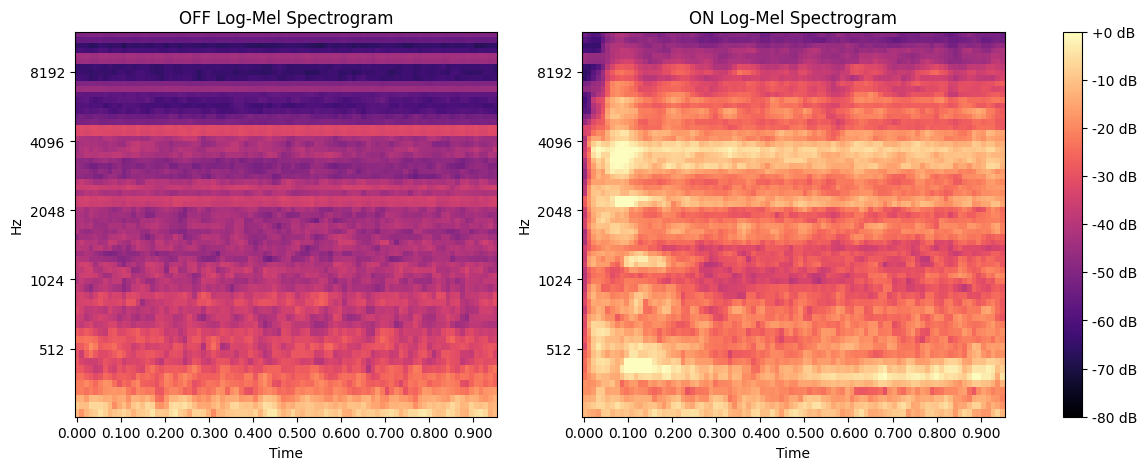

In [6]:
off_example = (
    window_manifest[
        (
            window_manifest["dataset_role"]
            == "development_A"
        )
        & (
            window_manifest["label"]
            == "OFF"
        )
    ]
    .iloc[0]
)

on_example = (
    window_manifest[
        (
            window_manifest["dataset_role"]
            == "development_A"
        )
        & (
            window_manifest["label"]
            == "ON"
        )
    ]
    .iloc[0]
)

off_signal = load_audio_window(
    off_example
)

on_signal = load_audio_window(
    on_example
)

off_log_mel = make_log_mel(
    off_signal
)

on_log_mel = make_log_mel(
    on_signal
)

print(
    "OFF Log-Mel shape:",
    off_log_mel.shape,
)

print(
    "ON Log-Mel shape:",
    on_log_mel.shape,
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

for axis, log_mel, title in [
    (
        axes[0],
        off_log_mel,
        "OFF Log-Mel Spectrogram",
    ),
    (
        axes[1],
        on_log_mel,
        "ON Log-Mel Spectrogram",
    ),
]:
    image = librosa.display.specshow(
        log_mel,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
        vmin=-80,
        vmax=0,
        cmap="magma",
        ax=axis,
    )

    axis.set_title(title)

fig.colorbar(
    image,
    ax=axes,
    format="%+2.0f dB",
)

plt.show()